In [37]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [38]:
def plot_chain_distribution(data, n_buckets, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    chain_lengths = data["length"]
    bucket_indices = range(n_buckets)
    
    ax.bar(bucket_indices, chain_lengths, width=0.3, alpha=0.7, color='black', edgecolor='black')
    
    mean_len = chain_lengths.mean()
    std_len = chain_lengths.std()
    max_len = chain_lengths.max()
    zero_buckets = (chain_lengths == 0).sum()
    
    stats = f'Mean: {mean_len:.2f}\nStd: {std_len:.2f}\nMax: {max_len}\nEmpty: {zero_buckets} ({zero_buckets/n_buckets*100:.1f}%)'
    ax.text(0.95, 0.95, stats, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
           fontsize=8)
    
    ax.set_title(f"{title} (n={n_buckets})", fontsize=10)
    ax.set_xlabel("Bucket number", fontsize=9)
    ax.set_ylabel("Chain length (words per bucket)", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

    return ax


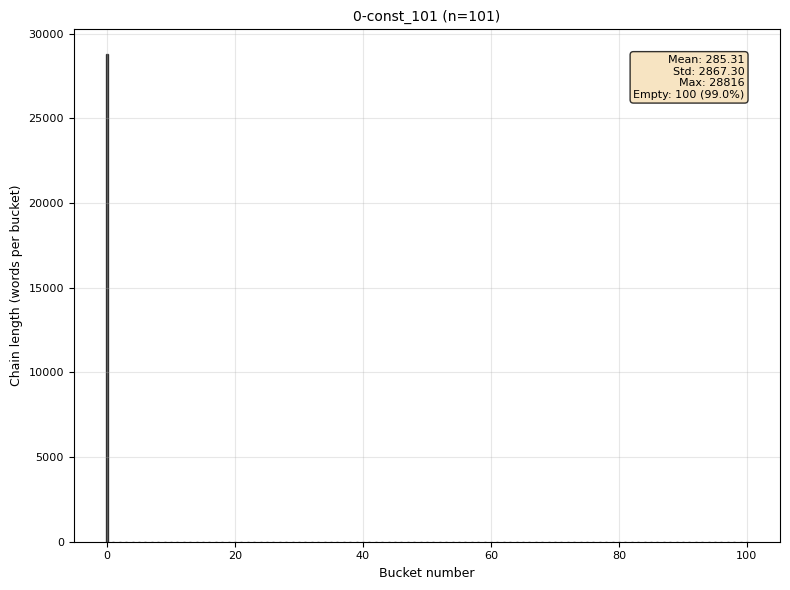

Saved: hash-table/plots/size_101/0-const_101.png


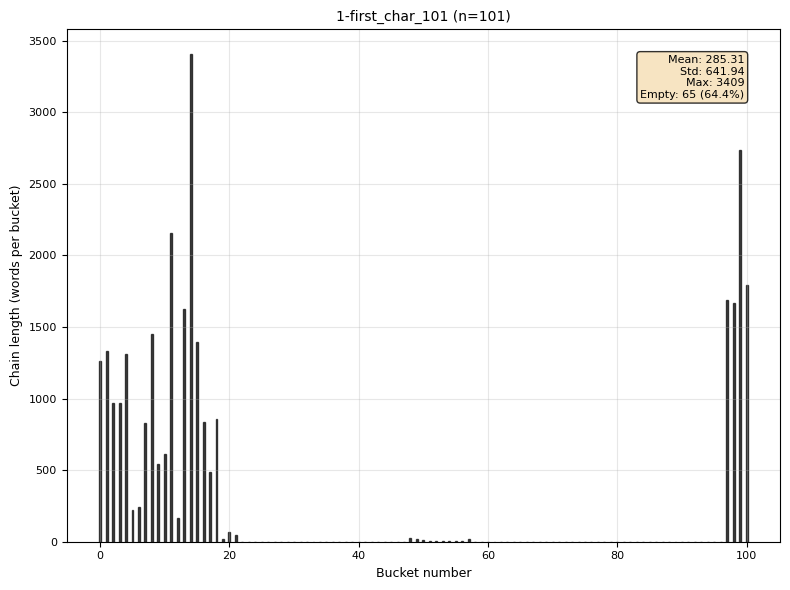

Saved: hash-table/plots/size_101/1-first_char_101.png


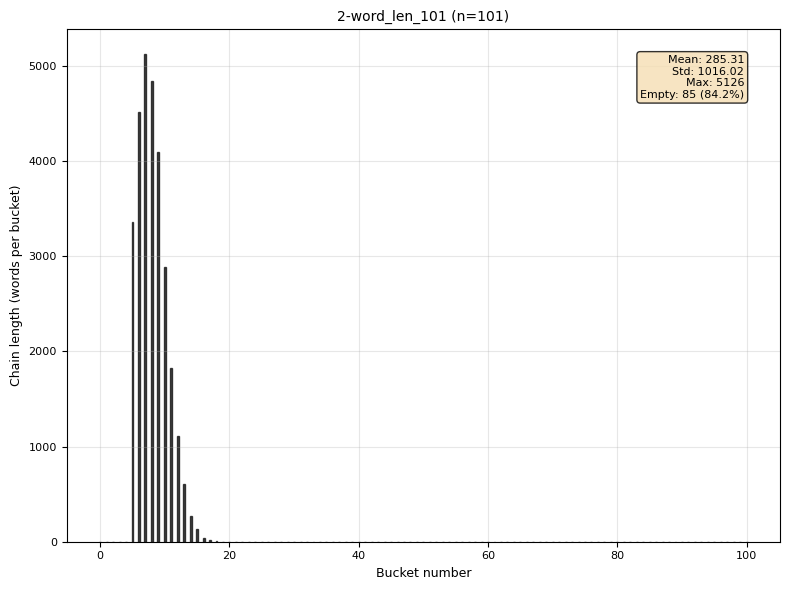

Saved: hash-table/plots/size_101/2-word_len_101.png


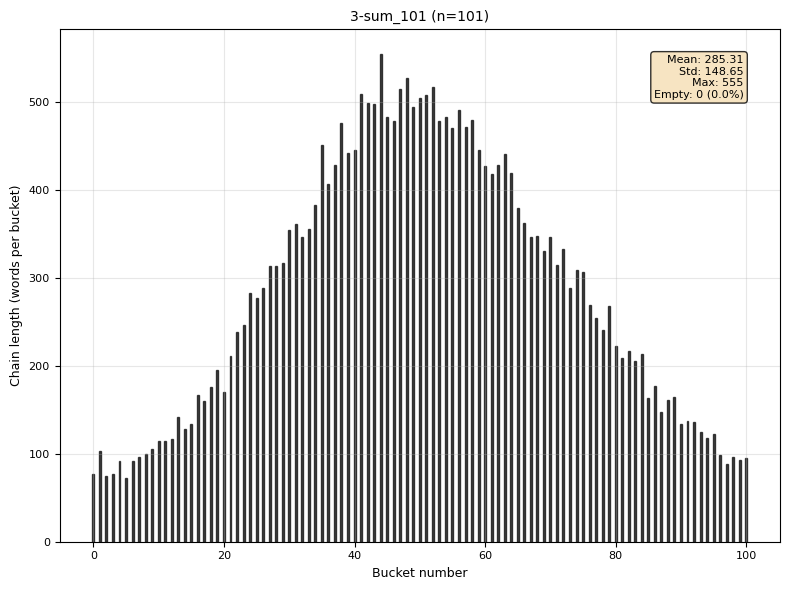

Saved: hash-table/plots/size_101/3-sum_101.png


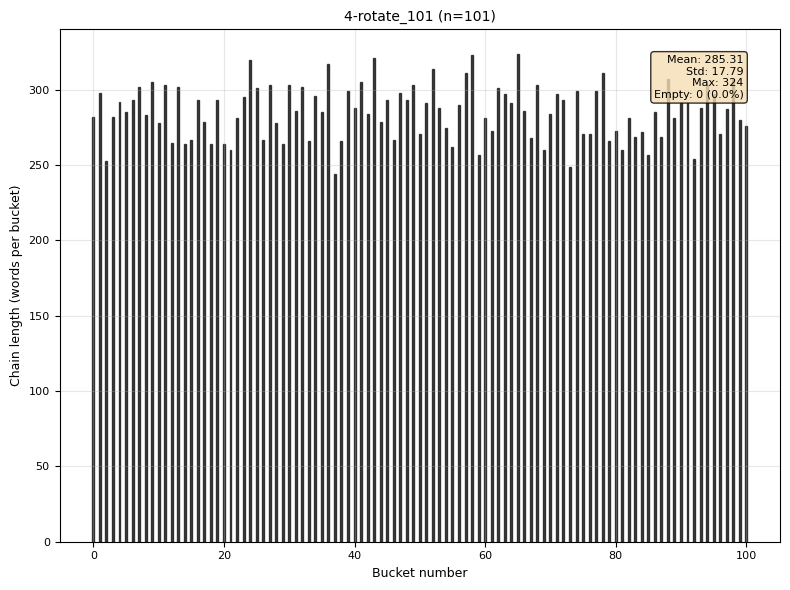

Saved: hash-table/plots/size_101/4-rotate_101.png


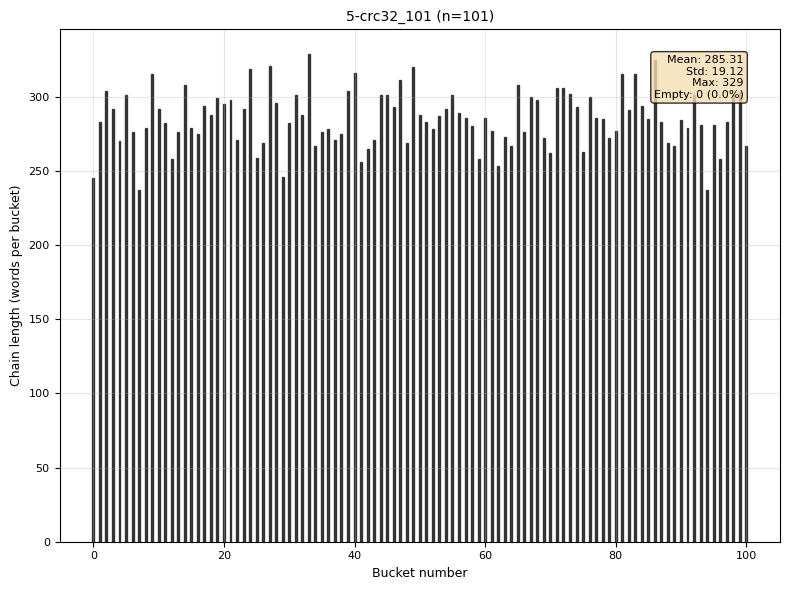

Saved: hash-table/plots/size_101/5-crc32_101.png


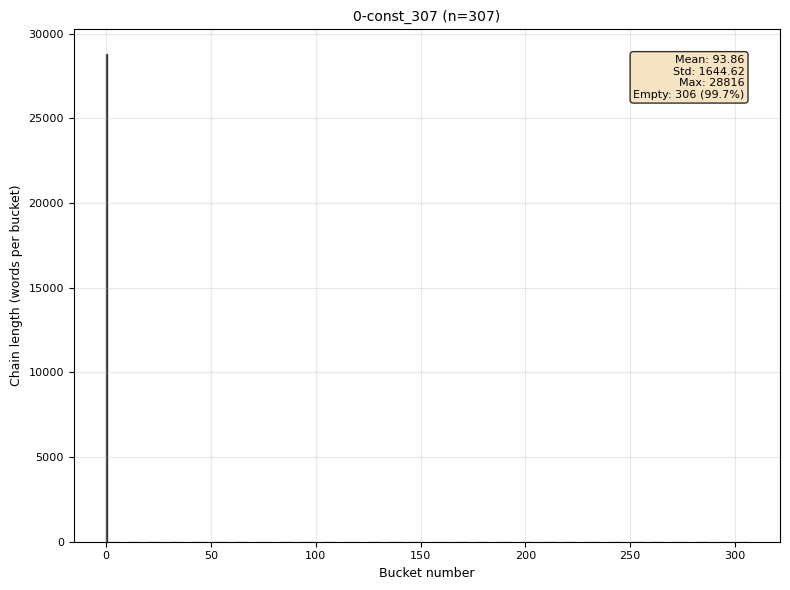

Saved: hash-table/plots/size_307/0-const_307.png


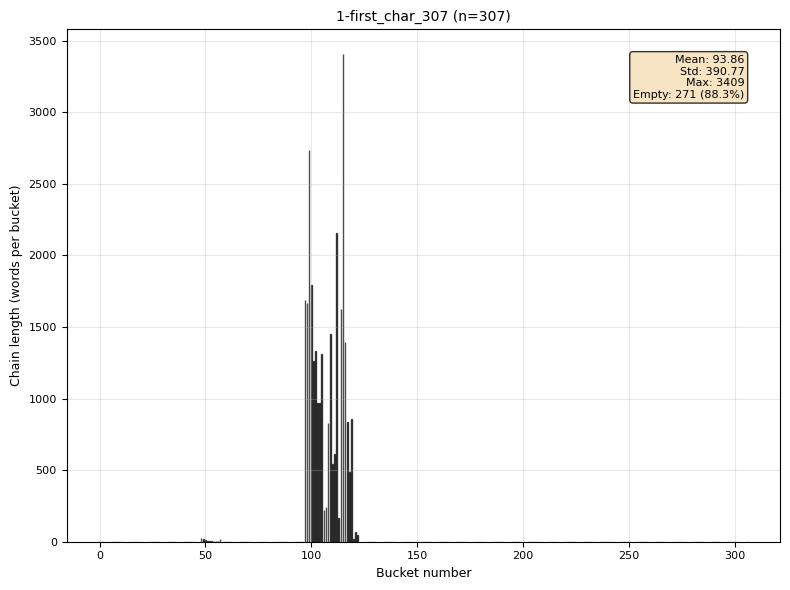

Saved: hash-table/plots/size_307/1-first_char_307.png


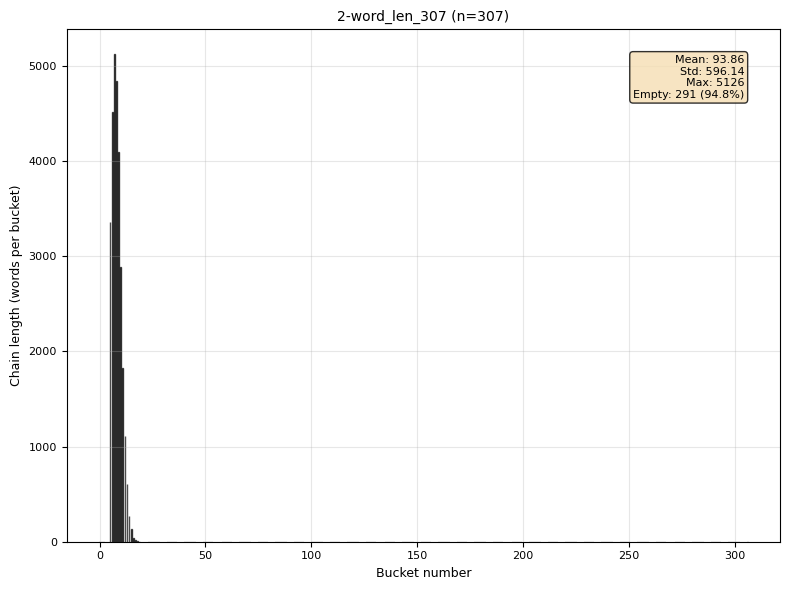

Saved: hash-table/plots/size_307/2-word_len_307.png


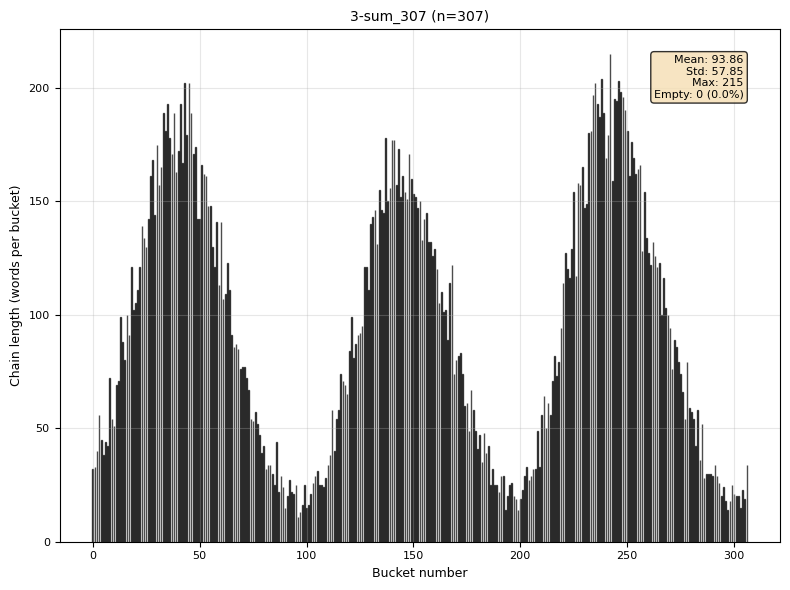

Saved: hash-table/plots/size_307/3-sum_307.png


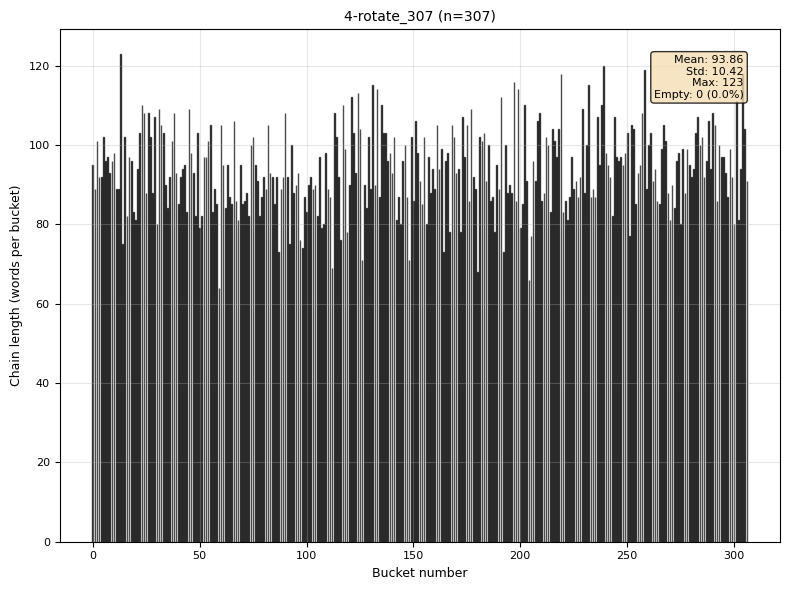

Saved: hash-table/plots/size_307/4-rotate_307.png


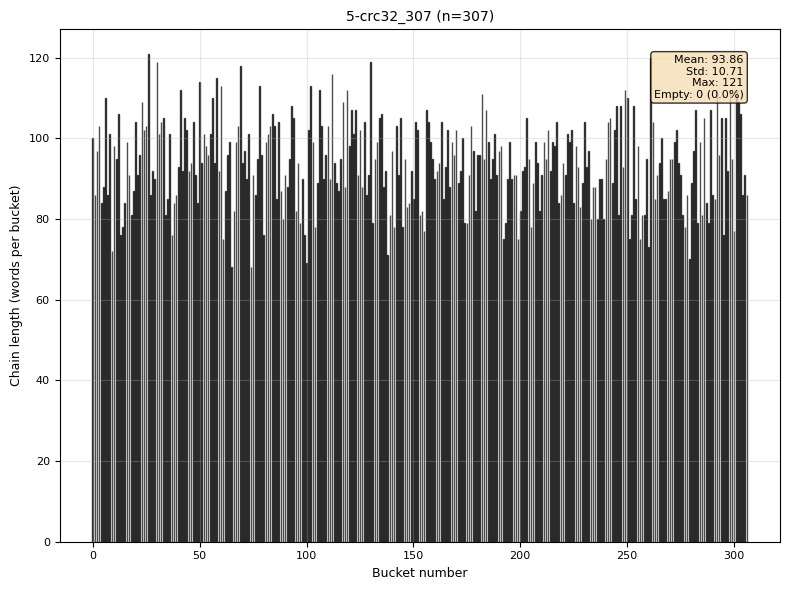

Saved: hash-table/plots/size_307/5-crc32_307.png


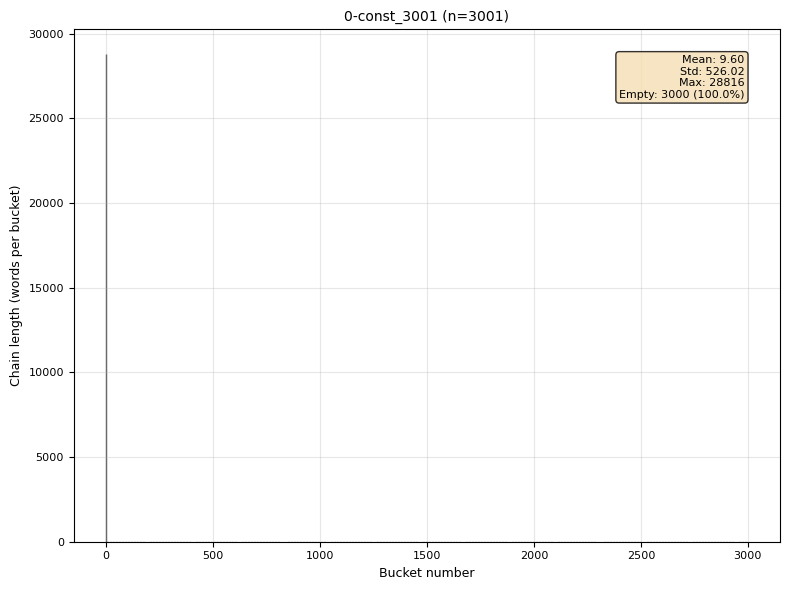

Saved: hash-table/plots/size_3001/0-const_3001.png


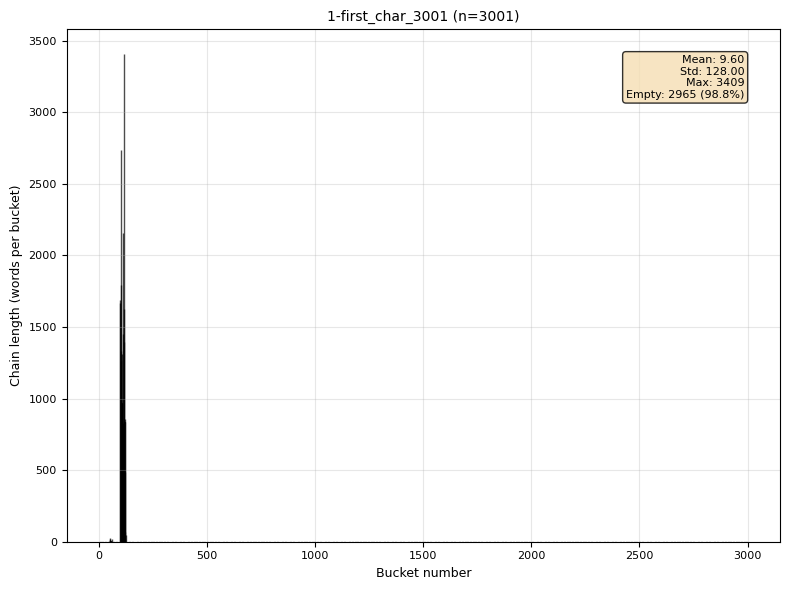

Saved: hash-table/plots/size_3001/1-first_char_3001.png


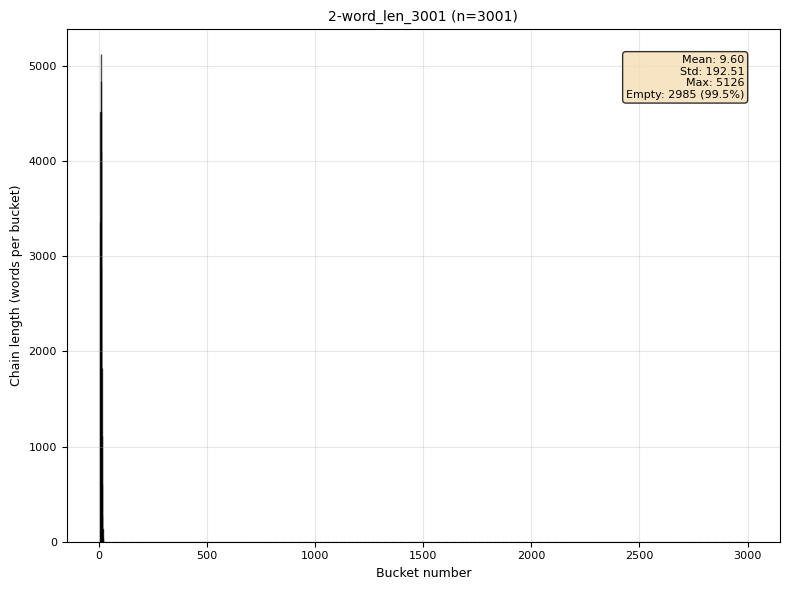

Saved: hash-table/plots/size_3001/2-word_len_3001.png


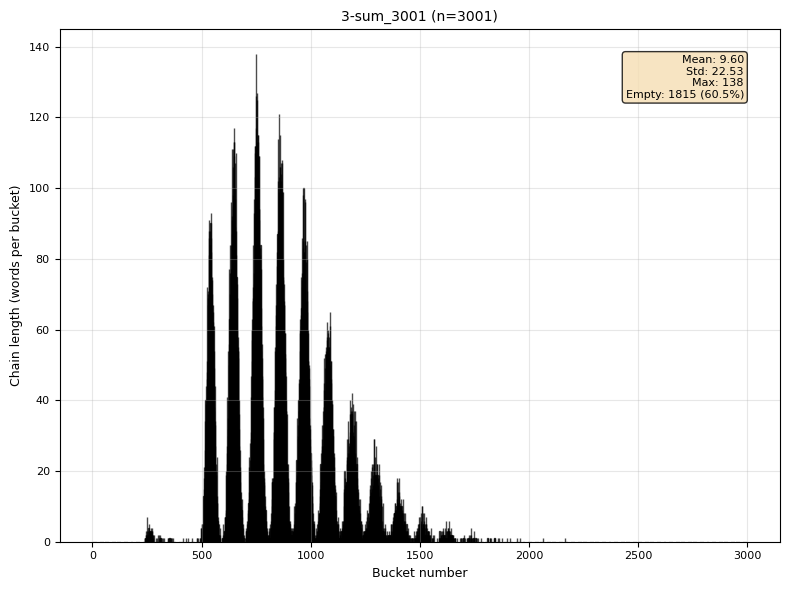

Saved: hash-table/plots/size_3001/3-sum_3001.png


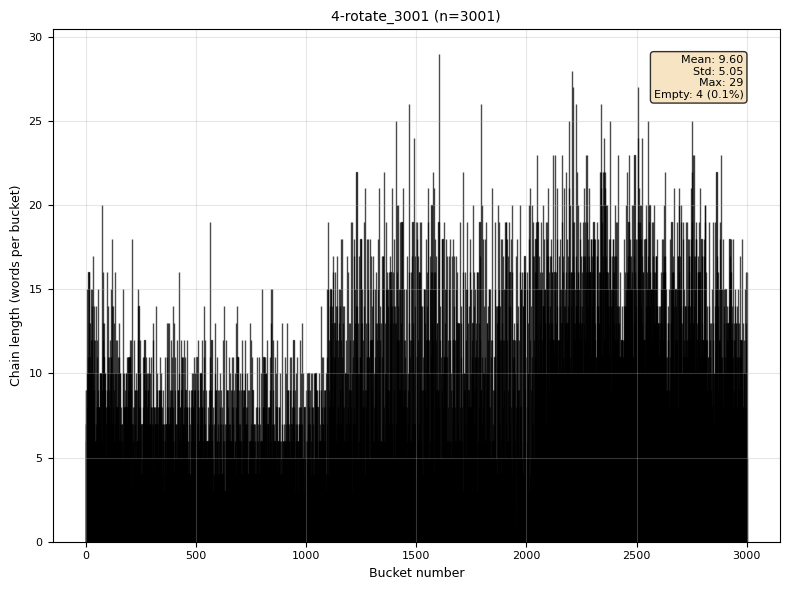

Saved: hash-table/plots/size_3001/4-rotate_3001.png


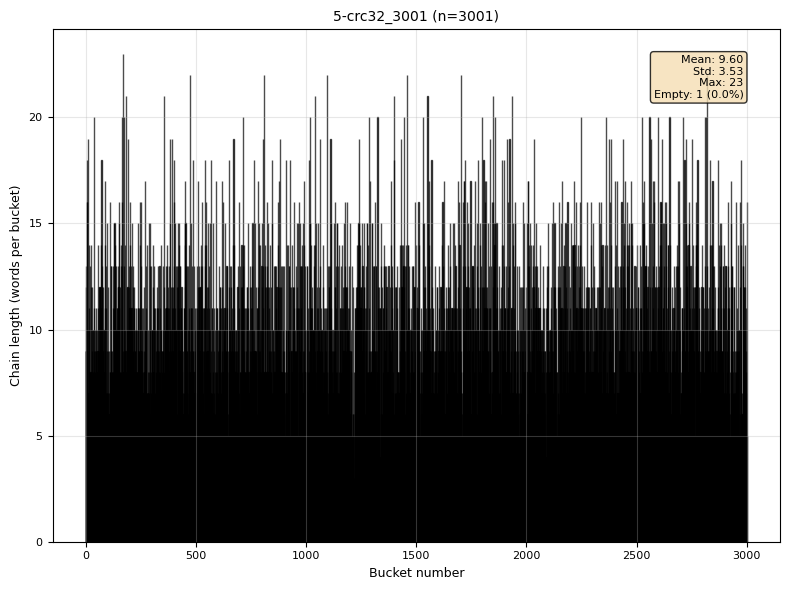

Saved: hash-table/plots/size_3001/5-crc32_3001.png


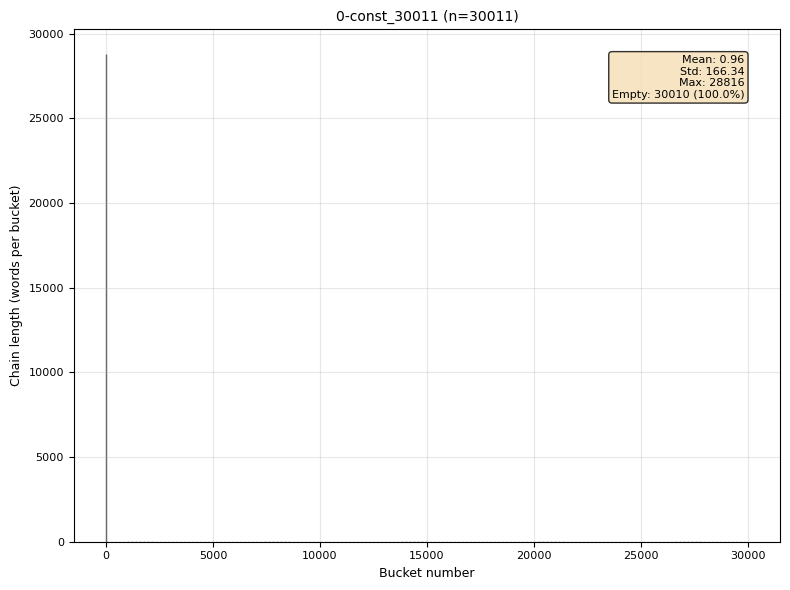

Saved: hash-table/plots/size_30011/0-const_30011.png


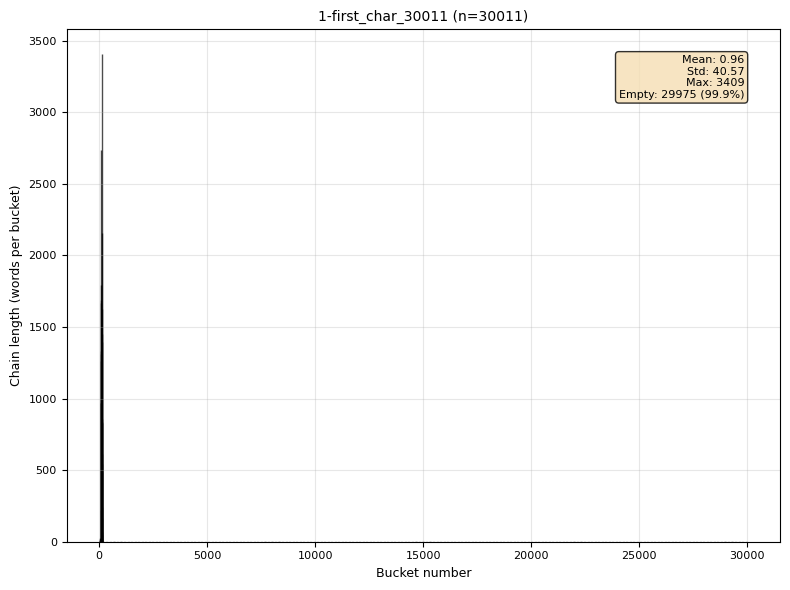

Saved: hash-table/plots/size_30011/1-first_char_30011.png


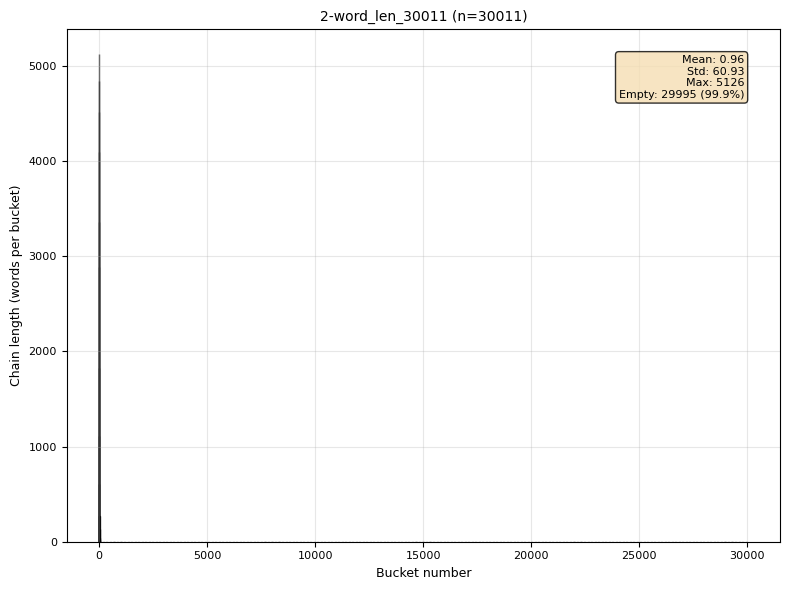

Saved: hash-table/plots/size_30011/2-word_len_30011.png


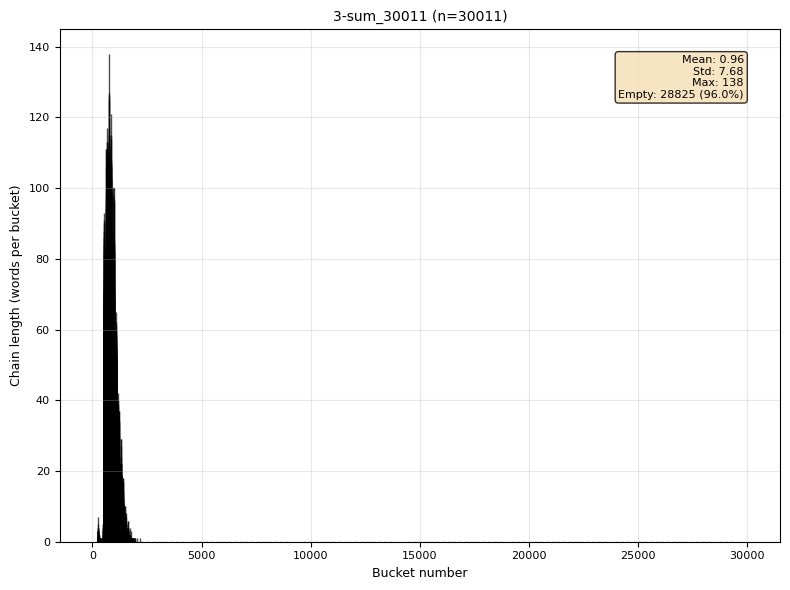

Saved: hash-table/plots/size_30011/3-sum_30011.png


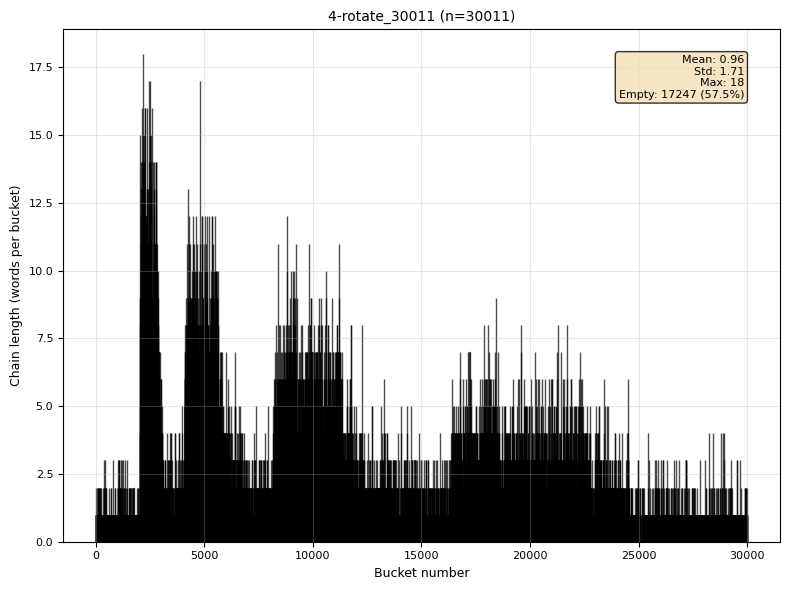

Saved: hash-table/plots/size_30011/4-rotate_30011.png


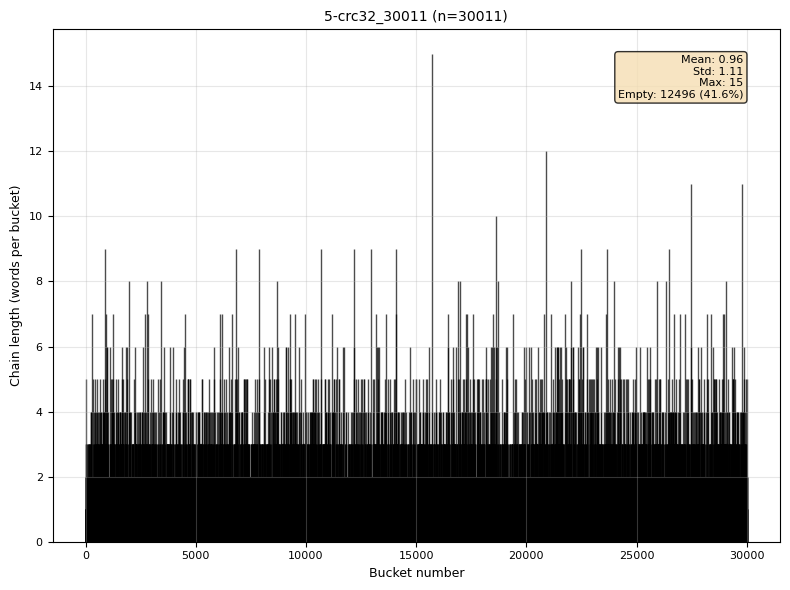

Saved: hash-table/plots/size_30011/5-crc32_30011.png


In [39]:
filenames = [
            "hash-table/data_csv/0-const_101.csv",
            "hash-table/data_csv/1-first_char_101.csv",
            "hash-table/data_csv/2-word_len_101.csv",
            "hash-table/data_csv/3-sum_101.csv",
            "hash-table/data_csv/4-rotate_101.csv",
            "hash-table/data_csv/5-crc32_101.csv",

            "hash-table/data_csv/0-const_307.csv",
            "hash-table/data_csv/1-first_char_307.csv",
            "hash-table/data_csv/2-word_len_307.csv",
            "hash-table/data_csv/3-sum_307.csv",
            "hash-table/data_csv/4-rotate_307.csv",
            "hash-table/data_csv/5-crc32_307.csv",

            "hash-table/data_csv/0-const_3001.csv",
            "hash-table/data_csv/1-first_char_3001.csv",
            "hash-table/data_csv/2-word_len_3001.csv",
            "hash-table/data_csv/3-sum_3001.csv",
            "hash-table/data_csv/4-rotate_3001.csv",
            "hash-table/data_csv/5-crc32_3001.csv",
            
            "hash-table/data_csv/0-const_30011.csv",
            "hash-table/data_csv/1-first_char_30011.csv",
            "hash-table/data_csv/2-word_len_30011.csv",
            "hash-table/data_csv/3-sum_30011.csv",
            "hash-table/data_csv/4-rotate_30011.csv",
            "hash-table/data_csv/5-crc32_30011.csv",
            ]

for filename in filenames:
    data = pd.read_csv(filename)
    n_buckets = len(data)
    short_name = filename.split('/')[-1].replace('.csv', '')  # "0-const_301"
    
    # Извлекаем размер (число после подчеркивания)
    size = short_name.split('_')[-1]  # "301", "3001", "30011"
    
    # Создаем папку с номером размера
    output_dir = f"hash-table/plots/size_{size}"
    os.makedirs(output_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_chain_distribution(data, n_buckets, short_name, ax)
    
    plt.tight_layout()
    
    
    output_path = os.path.join(output_dir, f"{short_name}.png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {output_path}")